In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mini_nn.layers import Linear, ReLu
from mini_nn.losses import BCEWithLogitLoss
from mini_nn.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

RAND_STATE = 42

In [2]:
# --- Create data ---
x, y = make_circles(5000, noise=0.02, random_state=RAND_STATE)
y = y.reshape(-1, 1)

# --- Peint data shape ---
print(f'x shape: {x.shape}')
print(f'y shape: {y.shape}')

x shape: (5000, 2)
y shape: (5000, 1)


In [3]:
# --- Split data into train and test sets ---
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=RAND_STATE,
                                                    test_size=0.2)
print(f'x train shape: {x_train.shape}')
print(f'x test shape: {x_test.shape}')
print(f'y train shape: {y_train.shape}')
print(f'y test shape: {y_test.shape}')

x train shape: (4000, 2)
x test shape: (1000, 2)
y train shape: (4000, 1)
y test shape: (1000, 1)


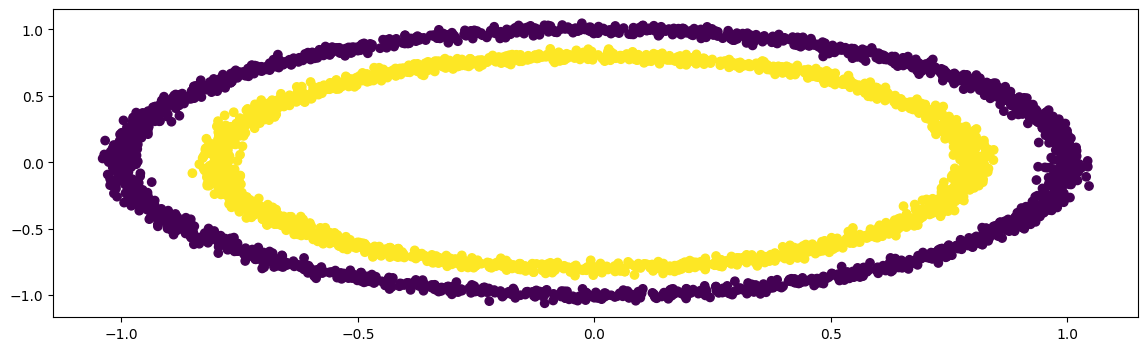

In [4]:
# --- Plot the train set ---
plt.figure(figsize=(14,4))
plt.scatter(x_train[:, 0],
            x_train[:, 1],
            c=y_train)

plt.show()

In [5]:
# --- Build a classification Neural Network ---

# --- set layers ---
input_layer = Linear(in_features = x_train.shape[1],
                     out_features=8,
                     initialize='he_normal')
input_relu = ReLu()

linear1 = Linear(in_features = 8,
                 out_features=4,
                 initialize='he_normal')
relu1 = ReLu()

linear2 = Linear(in_features=4,
                 out_features=1,
                 initialize='he_normal')

# --- Set loss function ---
loss_func = BCEWithLogitLoss()

# --- Set optimizer ---
optimizer = SGD(
    layers=[input_layer, linear1, linear2],
    learning_rate=0.01
)

In [6]:
# --- Training loop ---
def train_model(x_train, y_train, x_val, y_val, loss_function, optimizer, epochs):

    train_loss_hist = []
    val_loss_hist = []

    for ep in range(epochs):
        # --- forward propagation ---
        x = input_layer(x_train)
        x = input_relu(x)
        x = linear1(x)
        x = relu1(x)
        x = linear2(x)

        # --- evaluate epoch ---
        loss = loss_function(y_train, x)
        train_loss_hist.append(loss)

        # --- back propagation ---
        grad = loss_function.backward()
        grad = linear2.backward(grad)
        grad = relu1.backward(grad)
        grad = linear1.backward(grad)
        grad = input_relu.backward(grad)
        grad = input_layer.backward(grad)

        # --- validation test evaluation (forward propagation only) ---
        x = input_layer(x_val)
        x = input_relu(x)
        x = linear1(x)
        x = relu1(x)
        x = linear2(x)

        # --- test set: evaluate epoch ---
        val_loss = loss_function(y_val, x)
        val_loss_hist.append(val_loss)

        # --- optimize ---
        optimizer.step()

        if ep%10 == 0:
            print(
                f'epoch {ep:3d} | train loss={loss:.4f} | validation loss={val_loss:.4f}'
            )

    return train_loss_hist, val_loss_hist

In [7]:
train_loss, val_loss = train_model(x_train, y_train, x_test, y_test, loss_func, optimizer, 10000)

epoch   0 | train loss=0.8287 | validation loss=0.8299
epoch  10 | train loss=0.8023 | validation loss=0.8043
epoch  20 | train loss=0.7826 | validation loss=0.7853
epoch  30 | train loss=0.7677 | validation loss=0.7710
epoch  40 | train loss=0.7564 | validation loss=0.7603
epoch  50 | train loss=0.7476 | validation loss=0.7520
epoch  60 | train loss=0.7407 | validation loss=0.7456
epoch  70 | train loss=0.7352 | validation loss=0.7405
epoch  80 | train loss=0.7307 | validation loss=0.7362
epoch  90 | train loss=0.7270 | validation loss=0.7327
epoch 100 | train loss=0.7239 | validation loss=0.7297
epoch 110 | train loss=0.7213 | validation loss=0.7272
epoch 120 | train loss=0.7190 | validation loss=0.7249
epoch 130 | train loss=0.7169 | validation loss=0.7229
epoch 140 | train loss=0.7151 | validation loss=0.7211
epoch 150 | train loss=0.7134 | validation loss=0.7195
epoch 160 | train loss=0.7119 | validation loss=0.7181
epoch 170 | train loss=0.7105 | validation loss=0.7167
epoch 180 

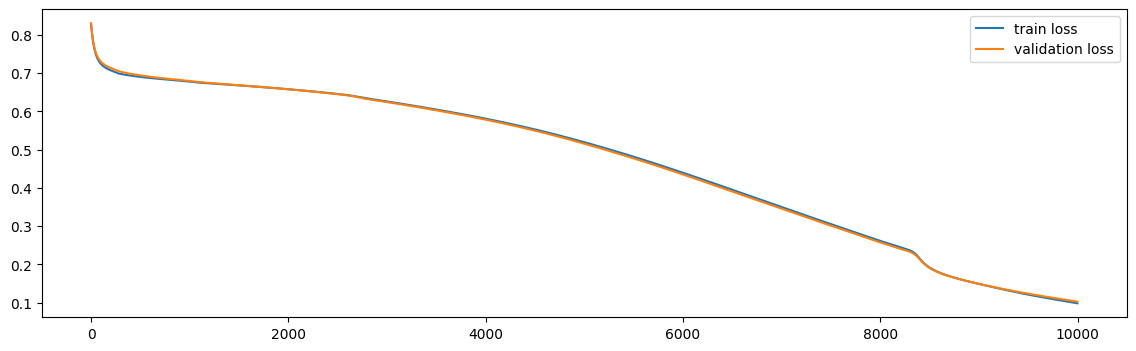

In [8]:
plt.figure(figsize=(14,4))

plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='validation loss')

plt.legend()
plt.show()

In [9]:
baseline_pred = np.full_like(y_train, 0.5)
baseline_loss = loss_func(y_train, baseline_pred)

print(f'Model loss better than baseline loss: {train_loss[-1]<baseline_loss}')

Model loss better than baseline loss: True
